# 2.12 Réduction de dimension

Les jeux de données géoscientifiques portent souvent de nombreuses caractéristiques corrélées : concentrations en oxydes dans une analyse de roche, milliers de mailles d'un champ climatique, dizaines d'attributs de formes d'onde. Réduire la dimension avant de modéliser est utile parce que :

1. Le coût de la plupart des algorithmes croît avec le nombre de dimensions d'entrée.
2. Les caractéristiques redondantes ajoutent du calcul sans ajouter d'information.
3. Les modèles plus simples sont plus robustes sur de petits jeux de données.
4. Moins de caractéristiques rendent les données plus faciles à comprendre.
5. La visualisation est plus aisée en deux ou trois dimensions.

Les techniques de réduction de dimension se rangent en deux catégories : la sélection de caractéristiques et l'extraction de caractéristiques.

## 1. Sélection de caractéristiques

La **sélection de caractéristiques** conserve un sous-ensemble des dimensions d'origine. Une approche de *sélection ascendante* part de la seule variable qui réduit le plus l'erreur et ajoute les variables une à une. Une *sélection descendante* part de toutes les variables et les retire une à une.

Un premier geste rapide consiste à regarder la matrice de corrélation : des caractéristiques fortement corrélées portent une information redondante, et l'on peut souvent en écarter une.

Nous utilisons une table géochimique synthétique issue du paquet du cours `mlgeo_synth`. Chaque ligne est une analyse sur roche totale : sept oxydes d'éléments majeurs en % massique (wt%), la densité, la susceptibilité magnétique et une étiquette de lithologie (basalte, andésite ou granite).

🖥️ [**Diapositives du cours — Séance 10 (mer. 21 oct.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec10_ai_ready_data.html)

In [1]:
# Import useful modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mlgeo_synth

In [2]:
geochem = mlgeo_synth.geochem_table(n=5000, seed=42)
geochem.head()

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si,label
0,46.477362,15.492878,10.941717,8.431905,12.363740,1.961059,0.186173,3.019760,0.000918,basalt
1,74.694298,12.765853,0.423512,0.000000,0.107761,3.799627,5.158455,2.664068,0.000117,granite
2,46.859296,15.176058,10.550278,8.055437,12.709424,3.110654,0.848197,2.930051,0.000774,basalt
3,48.345067,15.328732,10.327959,6.941860,11.812935,2.532933,0.000000,2.950357,0.001151,basalt
4,73.743099,14.204925,1.444934,0.000000,0.000000,4.465374,5.403987,2.640231,0.000211,granite


In [3]:
# The three lithology classes are imbalanced, as real map units usually are.
geochem["label"].value_counts()

label
granite     2794
basalt      1713
andesite     493
Name: count, dtype: int64

In [4]:
# Correlation matrix of the numeric features
features = geochem.drop(columns="label")
correlation_matrix = features.corr()
correlation_matrix.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

,SIO2,AL2O3,FEO,MGO,CAO,NA2O,K2O,density_g_cm3,mag_susc_si
SIO2,1.000000,-0.525544,-0.975183,-0.969474,-0.987661,0.562996,0.942286,-0.974967,-0.773102
AL2O3,-0.525544,1.000000,0.527165,0.453175,0.503327,-0.142044,-0.553921,0.480627,0.347349
FEO,-0.975183,0.527165,1.000000,0.964308,0.973085,-0.592634,-0.932990,0.949605,0.737387
MGO,-0.969474,0.453175,0.964308,1.000000,0.969187,-0.608404,-0.916507,0.949186,0.743006
CAO,-0.987661,0.503327,0.973085,0.969187,1.000000,-0.579000,-0.933333,0.965719,0.761805
NA2O,0.562996,-0.142044,-0.592634,-0.608404,-0.579000,1.000000,0.539344,-0.555580,-0.419288
K2O,0.942286,-0.553921,-0.932990,-0.916507,-0.933333,0.539344,1.000000,-0.915140,-0.707903
density_g_cm3,-0.974967,0.480627,0.949605,0.949186,0.965719,-0.555580,-0.915140,1.000000,0.764852
mag_susc_si,-0.773102,0.347349,0.737387,0.743006,0.761805,-0.419288,-0.707903,0.764852,1.000000


SiO2 est fortement anticorrélé à MgO, FeO et CaO, et la densité suit les oxydes mafiques. Deux effets produisent cette structure. D'abord la différenciation magmatique : à mesure qu'un magma évolue, SiO2 et K2O augmentent tandis que MgO, FeO et CaO diminuent. Ensuite la *fermeture* : les oxydes somment à environ 100 % massique, donc si l'un monte, les autres doivent descendre. Quelles caractéristiques écarteriez-vous au vu de cette matrice ?

## 2. Extraction de caractéristiques

L'**extraction de caractéristiques** construit un nouvel ensemble de dimensions, plus petit, formé de combinaisons des dimensions d'origine. Les méthodes peuvent être non supervisées (analyse en composantes principales, analyse en composantes indépendantes) ou supervisées (analyse discriminante linéaire).

## 3. Analyse en composantes principales

L'analyse en composantes principales (ACP, *PCA*) est une méthode non supervisée qui projette les données dans un espace de dimension inférieure avec une perte de variance minimale.

Soit $\mathbf{Y} = \mathbf{y}_1,\cdots,\mathbf{y}_n$ les données, mesurées $n$ fois sur plusieurs champs de mesure (la longueur de $\mathbf{y}$). Chaque **colonne** de $\mathbf{Y}$ représente une observation unique. Chaque **ligne** de $\mathbf{Y}$ représente un seul paramètre.

Pour réaliser une ACP :

1. Centrer les données en soustrayant la moyenne de chaque ligne de $\mathbf{Y}$ (et, en général, mettre chaque ligne à variance unitaire).
2. Calculer la matrice de covariance des données centrées, $\mathbf{C} = \frac{1}{n-1} \mathbf{Y}^{\ast}\mathbf{Y}$. La matrice de covariance est symétrique semi-définie positive : elle est donc diagonalisable.
3. Calculer la *décomposition en valeurs singulières (SVD)* :

$\mathbf{X} = \mathbf{U} \Sigma \mathbf{V}^T,$

où les colonnes de $\mathbf{V}$ sont les vecteurs propres, ou composantes principales. La première composante principale pointe dans la direction de plus forte variance.

### 3.1 La géométrie de l'ACP : un nuage gaussien tourné

Pour se forger une intuition, partons d'un nuage de points bidimensionnel : 10 000 observations tirées d'une gaussienne étirée et tournée.

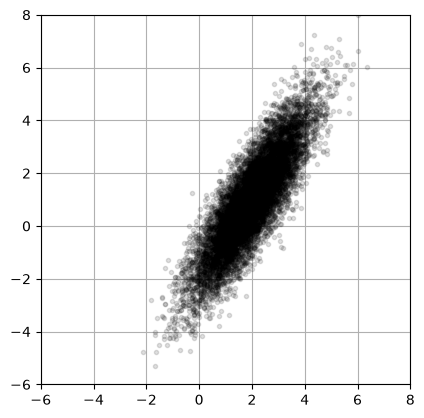

In [5]:
# Generate the toy data
rng = np.random.default_rng(42)

xC = np.array([2, 1])      # Center of data (mean)
sig = np.array([2, 0.5])   # Principal axes
theta = np.pi / 3          # Rotate cloud by pi/3
R = np.array([[np.cos(theta), -np.sin(theta)],     # Rotation matrix
              [np.sin(theta), np.cos(theta)]])
nPoints = 10000

# create the cloud of points (np.matmul can also be written @)
X = R @ np.diag(sig) @ rng.standard_normal((2, nPoints)) + np.diag(xC) @ np.ones((2, nPoints))

# plot the data
fig, ax1 = plt.subplots()
ax1.plot(X[0, :], X[1, :], '.', color='k', alpha=0.125)
ax1.grid()
ax1.set_xlim((-6, 8))
ax1.set_ylim((-6, 8))
ax1.set_aspect('equal')
plt.show()

#### *Étape 1* : soustraire la moyenne

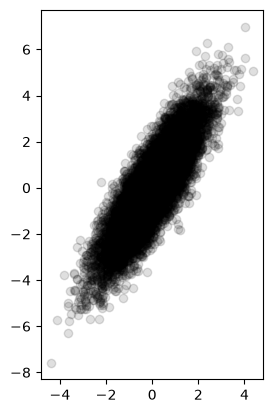

In [6]:
Xavg = np.mean(X, axis=1)          # Compute mean
B = X - Xavg[:, np.newaxis]        # Mean-subtracted data

plt.scatter(B[0, :], B[1, :], color='k', alpha=0.125)
plt.gca().set_aspect('equal')
plt.show()

In [7]:
# calculate the covariance matrix
covB = (B @ B.T) / nPoints
print(f"shape of B {B.shape} and shape of covB {covB.shape}")
print(covB)

shape of B (2, 10000) and shape of covB (2, 2)
[[1.21210083 1.65131023]
 [1.65131023 3.08978984]]


#### *Étape 2* : SVD de la matrice de covariance

In [8]:
U, S, VT = np.linalg.svd(covB, full_matrices=False)

print("eigenvalues (variances along each axis):", S)
print("eigenvectors (rows of VT):")
print(VT)

eigenvalues (variances along each axis): [4.05048593 0.25140474]
eigenvectors (rows of VT):
[[-0.50286768 -0.8643634 ]
 [-0.8643634   0.50286768]]


Les valeurs propres sont proches de $\sigma^2 = [4, 0.25]$, les carrés des longueurs des axes utilisés pour construire le nuage.

#### *Étape 3* : explorer le résultat

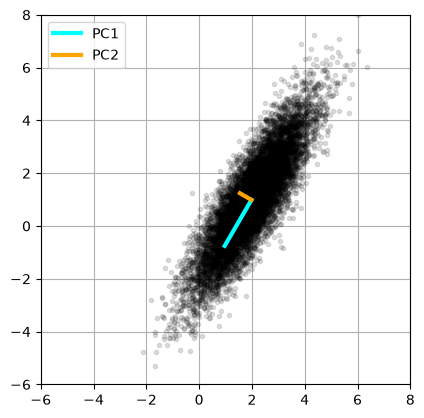

In [9]:
fig, ax2 = plt.subplots()
ax2.plot(X[0, :], X[1, :], '.', color='k', alpha=0.125)   # Plot data to overlay PCA
ax2.grid()
ax2.set_xlim((-6, 8))
ax2.set_ylim((-6, 8))
ax2.set_aspect('equal')

# Plot the eigenvectors, scaled by the standard deviation along each axis
for k, color in zip(range(2), ['cyan', 'orange']):
    scale = np.sqrt(S[k])
    ax2.plot([Xavg[0], Xavg[0] + VT[k, 0] * scale],
             [Xavg[1], Xavg[1] + VT[k, 1] * scale],
             '-', color=color, linewidth=3, label=f"PC{k+1}")
ax2.legend()
plt.show()

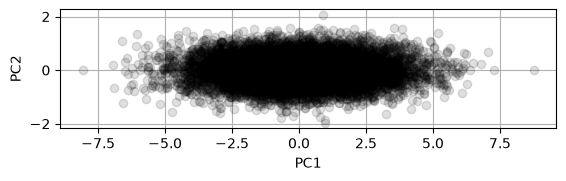

In [10]:
# Project the original data onto the principal axes
projected = B.T @ VT.T

plt.scatter(projected[:, 0], projected[:, 1], c='k', alpha=0.125)
ax = plt.gca()
ax.set_axisbelow(True)
ax.grid()
ax.set_aspect('equal')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

La projection fait tourner le nuage de sorte que la direction de plus grande variance se place le long de l'axe horizontal. L'ACP a retrouvé la rotation que nous avons utilisée pour engendrer les données.

### 3.2 ACP sur une table géochimique

Appliquons maintenant l'ACP à la table géochimique de la section 1. Les caractéristiques doivent d'abord être standardisées : les oxydes couvrent des dizaines de % massique tandis que la susceptibilité magnétique est de l'ordre de 10$^{-3}$ SI, et sans mise à l'échelle les caractéristiques de grande amplitude domineraient la covariance.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_names = features.columns.tolist()

scaler = StandardScaler()
geochem_scaled = scaler.fit_transform(features)

pca = PCA()
geochem_pca = pca.fit_transform(geochem_scaled)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

Explained variance ratio: [0.782 0.097 0.06  0.037 0.01  0.006 0.004 0.003 0.001]


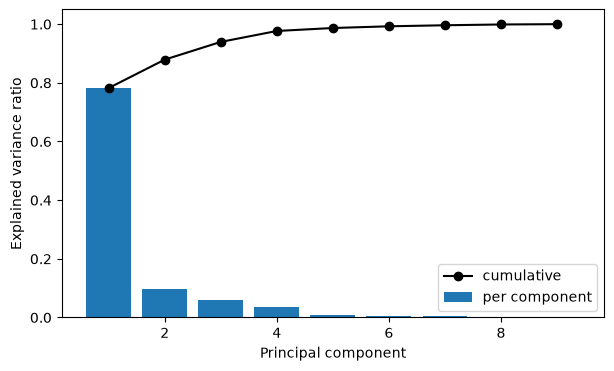

In [12]:
# Scree plot: variance explained by each component
n_pc = len(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(1, n_pc + 1), pca.explained_variance_ratio_, label="per component")
ax.plot(np.arange(1, n_pc + 1), np.cumsum(pca.explained_variance_ratio_),
        'o-', color='k', label="cumulative")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.legend()
plt.show()

Une seule composante capture l'essentiel de la variance, et deux en capturent la quasi-totalité. Les données vivent sur une surface de dimension bien plus basse que ne le laissent croire les neuf caractéristiques mesurées.

**Les saturations nous disent ce que signifient les composantes.** Chaque composante principale est une combinaison pondérée des caractéristiques d'origine ; les poids s'appellent les saturations (*loadings*).

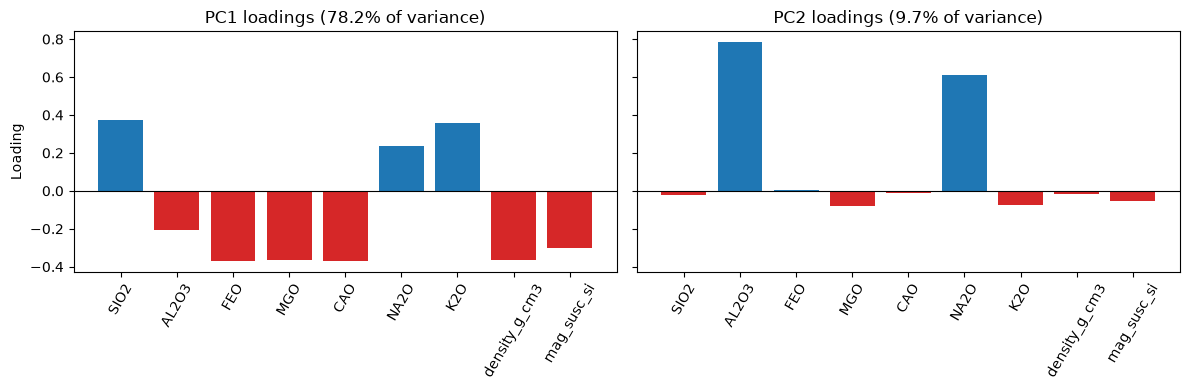

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for k, ax in enumerate(axes):
    loadings = pca.components_[k]
    colors = ['tab:red' if v < 0 else 'tab:blue' for v in loadings]
    ax.bar(feature_names, loadings, color=colors)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_title(f"PC{k+1} loadings "
                 f"({100*pca.explained_variance_ratio_[k]:.1f}% of variance)")
    ax.tick_params(axis='x', rotation=60)
axes[0].set_ylabel("Loading")
plt.tight_layout()
plt.show()

Sur PC1, SiO2, K2O et Na2O ont un signe tandis que MgO, FeO, CaO, la densité et la susceptibilité magnétique ont l'autre. C'est exactement la structure de corrélation observée à la section 1 : la fermeture des oxydes plus la différenciation magmatique. PC1 joue le rôle d'un **indice de différenciation**. Le score PC1 d'un échantillon dit où il se situe sur le spectre basalte-granite, en un seul nombre.

Notez que le signe d'une composante est arbitraire : la SVD peut renvoyer l'une ou l'autre orientation, seuls les signes relatifs des saturations comptent.

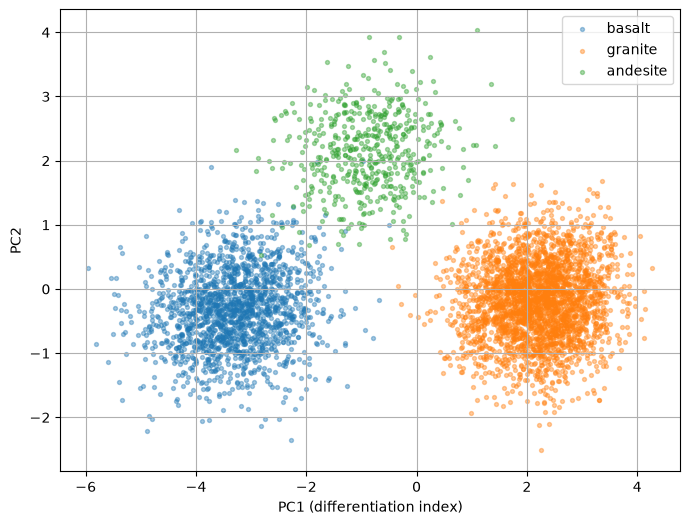

In [14]:
# Scatter of the first two PCs, colored by lithology
fig, ax = plt.subplots(figsize=(8, 6))
for lith in geochem["label"].unique():
    mask = (geochem["label"] == lith).to_numpy()
    ax.scatter(geochem_pca[mask, 0], geochem_pca[mask, 1],
               s=8, alpha=0.4, label=lith)
ax.set_xlabel("PC1 (differentiation index)")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(True)
plt.show()

L'ACP n'a jamais vu les étiquettes, et pourtant les trois lithologies se séparent le long de PC1, parce que la composition et la lithologie sont pilotées par le même processus sous-jacent. C'est une issue fréquente et utile : une méthode non supervisée retrouve un axe physiquement interprétable.

*Note pratique :* la SVD complète est coûteuse pour de grandes matrices. Scikit-learn bascule automatiquement sur un solveur d'**ACP randomisée** quand les données dépassent 500 x 500 et que le nombre de composantes demandées est inférieur à 80 % de la plus petite dimension.

### 3.3 Analyse en EOF d'un champ climatique

Appliquée à des données spatio-temporelles, l'ACP donne deux objets liés :

* **Les fonctions orthogonales empiriques (EOF)** : les vecteurs propres spatiaux de la covariance des données. Chaque EOF est une carte qui explique une part de la variance totale. En sciences du climat, les EOF identifient des motifs dominants comme des modes de circulation ou des structures d'anomalies de température.
* **Les composantes principales (PC)** : les séries temporelles qui disent avec quelle force chaque EOF s'exprime à chaque pas de temps.

Ensemble, EOF et PC décrivent la variabilité spatio-temporelle du jeu de données.

Nous utilisons `mlgeo_synth.climate_field`, qui engendre 30 ans d'anomalies mensuelles de température sur une grille globale. Le générateur y plante des structures connues — un mode saisonnier, un mode zonal (de type terre/océan) et une tendance de réchauffement — et les renvoie dans un dictionnaire `truth`, ce qui nous permet de vérifier si l'analyse en EOF les retrouve.

In [15]:
field, truth = mlgeo_synth.climate_field(
    n_lat=40, n_lon=80, n_months=360, trend_c_per_decade=0.25, seed=42
)
lat = truth["lat"]
lon = truth["lon"]
n_months, n_lat, n_lon = field.shape
print("field shape (months, lat, lon):", field.shape)
print("truth keys:", list(truth.keys()))

field shape (months, lat, lon): (360, 40, 80)
truth keys: ['lat', 'lon', 'seasonal_pattern', 'zonal_pattern', 'trend_c_per_decade']


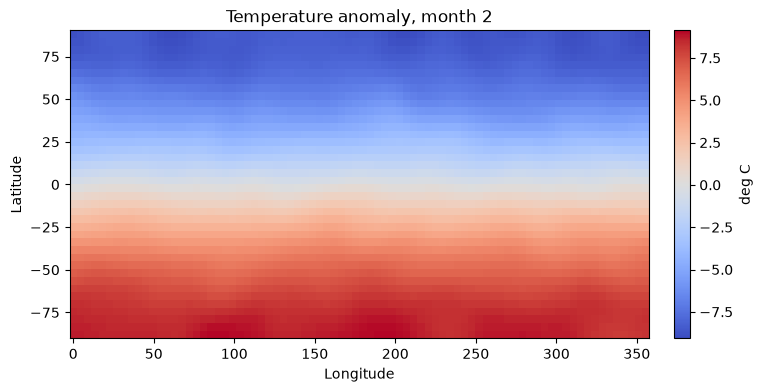

In [16]:
# One month of the field
plt.figure(figsize=(8, 4))
plt.pcolormesh(lon, lat, field[1], cmap='coolwarm', shading='auto')
plt.title('Temperature anomaly, month 2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='deg C', fraction=0.025, pad=0.04)
plt.show()

**Pondération par l'aire.** La grille est à pas angulaire constant : les mailles sont régulièrement espacées en latitude et en longitude. Mais l'aire physique d'une maille se rétrécit vers les pôles en $\cos(\phi)$. Sans correction, la matrice de covariance surreprésente les hautes latitudes — beaucoup de mailles, peu d'aire réelle. La correction standard consiste à multiplier chaque point de grille par $\sqrt{\cos(\phi)}$ avant la SVD, pour que la contribution de chaque maille à la *variance* (qui est quadratique en les données) soit proportionnelle à son aire.

In [17]:
# Remove the time mean at each grid point, then apply area weights
anom = field - field.mean(axis=0)
w = np.sqrt(np.cos(np.deg2rad(lat)))          # shape (n_lat,)
anom_w = anom * w[None, :, None]

# Reshape to a (time x space) matrix and take the SVD
Xmat = anom_w.reshape(n_months, n_lat * n_lon)
U, S, VT = np.linalg.svd(Xmat, full_matrices=False)

variance_fraction = S**2 / np.sum(S**2)
print("Variance fraction of first 5 modes:", np.round(variance_fraction[:5], 3))

Variance fraction of first 5 modes: [0.955 0.038 0.006 0.    0.   ]


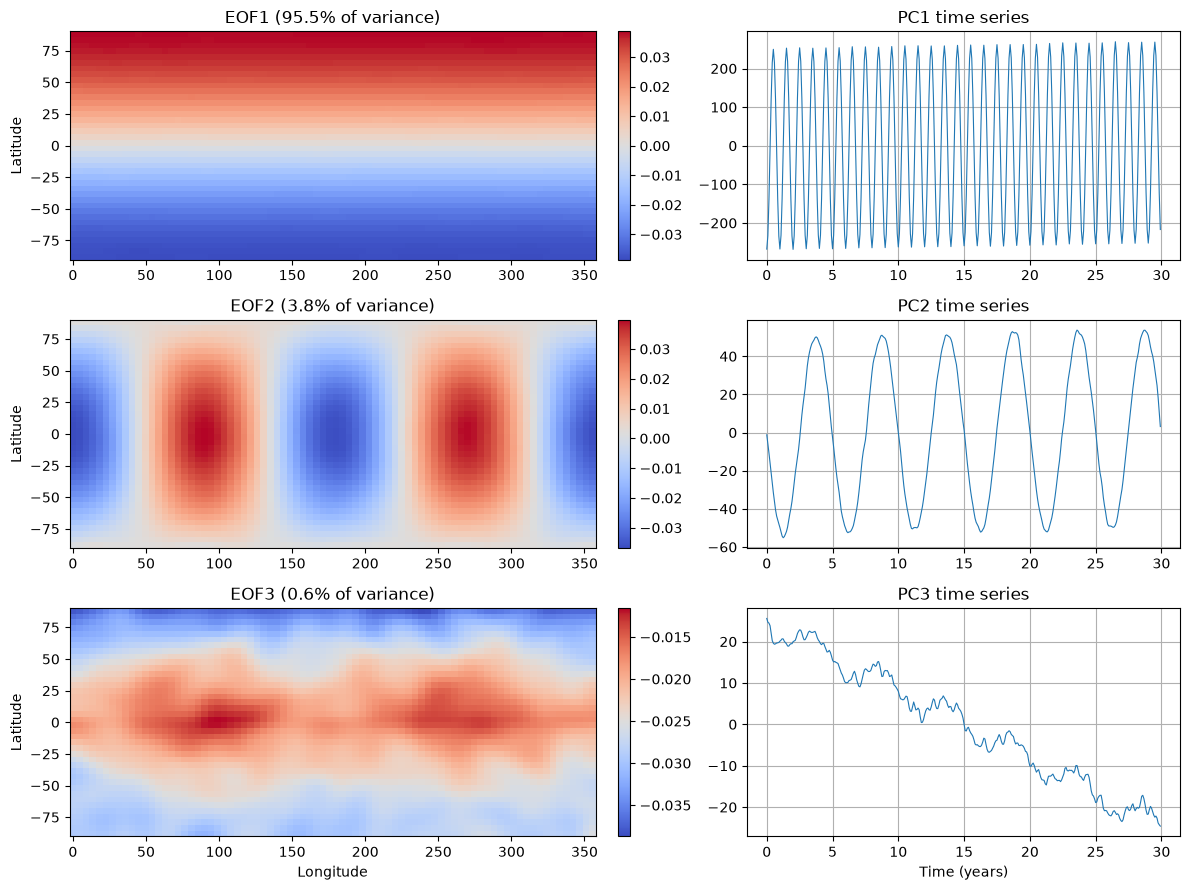

In [18]:
n_modes = 3
# Rows of VT are the EOFs of the *weighted* field; divide the weights back
# out to display physical patterns.
eofs = VT[:n_modes].reshape(n_modes, n_lat, n_lon) / w[None, :, None]
# PC time series: projection of the data on each EOF
pcs = U[:, :n_modes] * S[:n_modes]

fig, axes = plt.subplots(n_modes, 2, figsize=(12, 3 * n_modes),
                         gridspec_kw={'width_ratios': [1.3, 1]})
time_years = np.arange(n_months) / 12
for k in range(n_modes):
    im = axes[k, 0].pcolormesh(lon, lat, eofs[k], cmap='coolwarm', shading='auto')
    axes[k, 0].set_title(f"EOF{k+1} ({100*variance_fraction[k]:.1f}% of variance)")
    axes[k, 0].set_ylabel("Latitude")
    fig.colorbar(im, ax=axes[k, 0], fraction=0.025, pad=0.04)
    axes[k, 1].plot(time_years, pcs[:, k], linewidth=0.8)
    axes[k, 1].set_title(f"PC{k+1} time series")
    axes[k, 1].grid(True)
axes[-1, 0].set_xlabel("Longitude")
axes[-1, 1].set_xlabel("Time (years)")
plt.tight_layout()
plt.show()

**Avons-nous retrouvé la structure plantée ?** Le dictionnaire `truth` contient les motifs saisonnier et zonal utilisés par le générateur. Nous les comparons aux EOF retrouvées par une corrélation de motifs spatiaux. Le signe d'une EOF est arbitraire (une EOF et son opposée décrivent le même mode, avec la PC retournée en conséquence) : nous regardons donc la valeur absolue de la corrélation.

In [19]:
def pattern_corr(a, b):
    """Pearson correlation between two flattened maps."""
    return np.corrcoef(a.ravel(), b.ravel())[0, 1]

planted = {"seasonal_pattern": truth["seasonal_pattern"],
           "zonal_pattern": truth["zonal_pattern"]}

print(f"{'':>12s}" + "".join(f"{name:>20s}" for name in planted))
for k in range(n_modes):
    row = f"{'EOF' + str(k+1):>12s}"
    for name, pat in planted.items():
        row += f"{pattern_corr(eofs[k], pat):>20.2f}"
    print(row)

                seasonal_pattern       zonal_pattern
        EOF1                1.00               -0.00
        EOF2                0.00               -1.00
        EOF3               -0.12               -0.23


EOF1 correspond au motif saisonnier planté et EOF2 au motif zonal planté, avec des corrélations de +/-1. Une corrélation de -1 vaut ici tout autant que +1 : c'est le même mode, avec la carte et sa PC toutes deux retournées. Regardez aussi les séries temporelles des PC : la PC saisonnière oscille avec une période de 12 mois, la PC zonale varie sans tendance, et PC3 — dont la carte se concentre aux hautes latitudes nord — dérive régulièrement dans une direction. C'est la tendance de réchauffement plantée de 0,25 °C par décennie, amplifiée vers l'Arctique (que la dérive apparaisse vers le haut ou vers le bas dépend là encore du signe arbitraire de l'EOF).

**Limites de l'ACP sur des données spatio-temporelles.** Les EOF sont contraintes à être orthogonales, alors que les modes physiques de variabilité ne le sont pas : une seule EOF peut donc mélanger plusieurs processus et en scinder d'autres. L'ACP est linéaire, donc une dynamique non linéaire se répartit sur de nombreuses composantes. Les tendances de grande échelle peuvent dominer les premiers modes et masquer des signaux locaux. Et les résultats sont sensibles aux choix de prétraitement : retirer ou non le cycle saisonnier, comment mettre les variables à l'échelle, comment pondérer la grille. Traitez les EOF comme une description de la variance, pas automatiquement comme des modes physiques.

## 4. Analyse en composantes indépendantes

L'analyse en composantes indépendantes (ICA) sépare un signal multivarié en composantes additives, statistiquement indépendantes et non gaussiennes. C'est une forme de séparation aveugle de sources.

Différences avec l'ACP :

* L'ACP trouve des axes orthogonaux qui maximisent la variance, à partir des statistiques d'ordre deux (la covariance). Ses composantes sont décorrélées mais pas nécessairement indépendantes.
* L'ICA trouve des composantes statistiquement indépendantes, pas nécessairement orthogonales, en exploitant la non-gaussianité. Elle exige que les sources soient non gaussiennes.

En géosciences, l'ICA sert à la séparation aveugle de sources quand plusieurs processus inconnus sont mélangés dans les mesures — séparer par exemple les contributions sismique, hydrologique et saisonnière dans des séries temporelles géodésiques.

La démonstration classique : trois signaux sources connus sont mélangés vers trois « récepteurs », et FastICA les démélange.

In [20]:
from scipy import signal
from sklearn.decomposition import FastICA

rng = np.random.default_rng(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

# create 3 source signals
s1 = np.sin(2 * time)                    # sinusoid
s2 = np.sign(np.sin(3 * time))           # square wave
s3 = signal.sawtooth(2 * np.pi * time)   # sawtooth

S_true = np.c_[s1, s2, s3]
S_true += 0.2 * rng.standard_normal(S_true.shape)   # add noise
S_true /= S_true.std(axis=0)                        # standardize

# Mix the sources: 3 signals recorded at 3 receivers
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # mixing matrix
X_mixed = S_true @ A.T

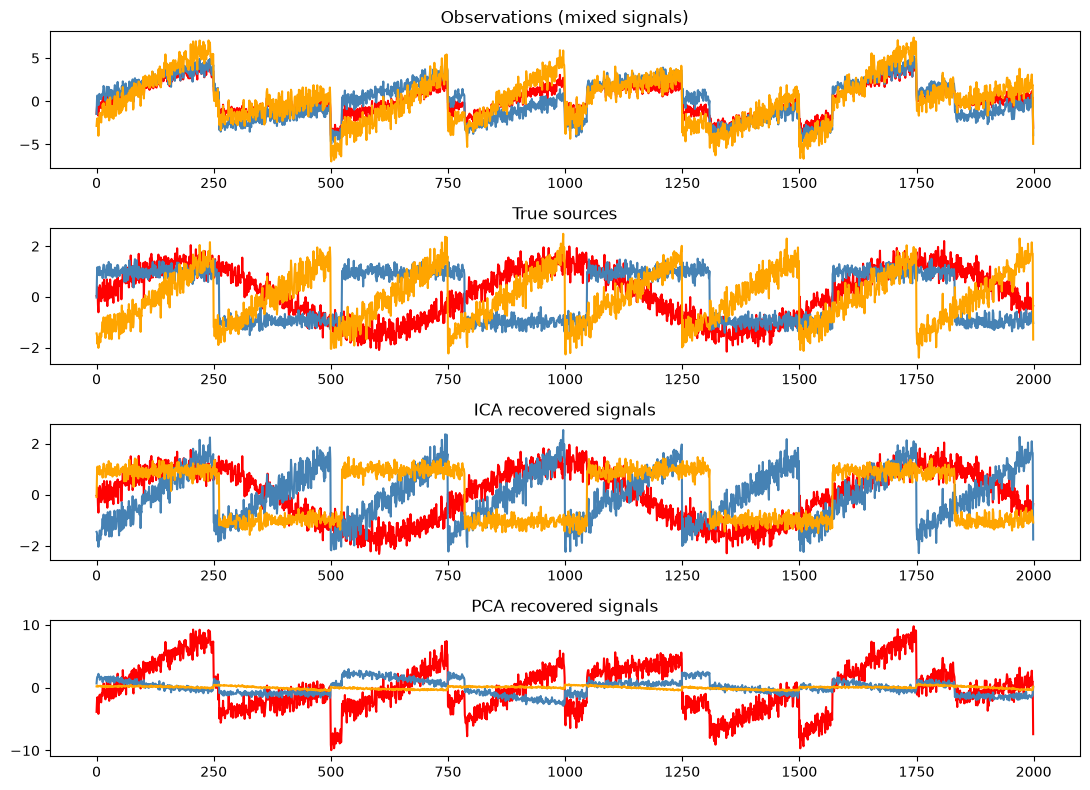

In [21]:
# Unmix with ICA; compare with PCA
ica = FastICA(n_components=3, random_state=0)
S_ica = ica.fit_transform(X_mixed)

pca3 = PCA(n_components=3)
S_pca = pca3.fit_transform(X_mixed)

plt.figure(figsize=(11, 8))
models = [X_mixed, S_true, S_ica, S_pca]
names = ['Observations (mixed signals)',
         'True sources',
         'ICA recovered signals',
         'PCA recovered signals']
colors = ['red', 'steelblue', 'orange']
for ii, (model, name) in enumerate(zip(models, names), 1):
    plt.subplot(4, 1, ii)
    plt.title(name)
    for sig_, color in zip(model.T, colors):
        plt.plot(sig_, color=color)
plt.tight_layout()
plt.show()

L'ICA retrouve les trois sources (à l'ordre, au signe et à l'échelle près). L'ACP, non : ses composantes orthogonales de variance maximale restent des mélanges des sources.

## 5. t-SNE pour la visualisation

L'ACP est linéaire. Le t-SNE (*t-distributed Stochastic Neighbor Embedding*) est une méthode non linéaire conçue pour la visualisation : elle place les points en 2D de sorte que des voisins dans l'espace de grande dimension restent voisins dans le plan. Elle préserve bien la structure locale, mais les distances *entre* groupes sur un graphique t-SNE n'ont pas de sens, et elle est trop lente pour les grands jeux de données — nous sous-échantillonnons donc.

Le paramètre `perplexity` fixe en gros le nombre de voisins que chaque point prend en compte. De petites valeurs fragmentent les données en une multitude de petits amas ; de grandes valeurs brouillent le détail local. Essayez toujours plusieurs valeurs.

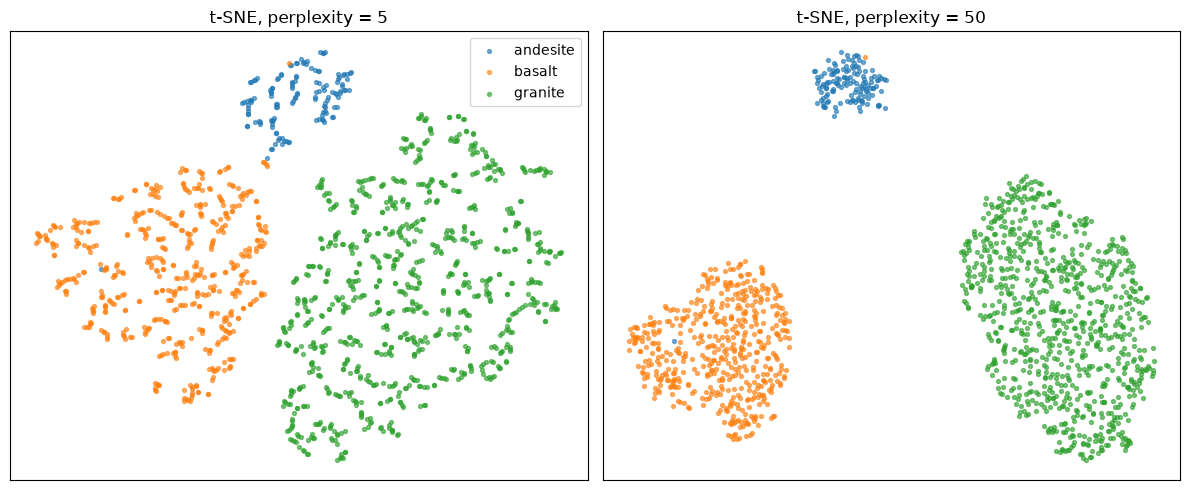

In [22]:
from sklearn.manifold import TSNE

# Subsample the standardized geochemical table for speed
rng = np.random.default_rng(42)
idx = rng.choice(len(geochem), size=1500, replace=False)
X_sub = geochem_scaled[idx]
labels_sub = geochem["label"].to_numpy()[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, perp in zip(axes, [5, 50]):
    emb = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_sub)
    for lith in np.unique(labels_sub):
        mask = labels_sub == lith
        ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6, label=lith)
    ax.set_title(f"t-SNE, perplexity = {perp}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].legend()
plt.tight_layout()
plt.show()

Les deux plongements séparent les lithologies, mais la géométrie change avec la perplexité — un rappel que les graphiques t-SNE sont qualitatifs. **UMAP** est une alternative populaire et plus rapide, aux objectifs voisins ; elle n'est pas installée dans l'environnement du cours, mais vous pouvez l'ajouter avec le paquet `umap-learn` si vous voulez comparer.

## 6. Autres techniques

1. [Projections aléatoires](https://scikit-learn.org/stable/modules/random_projection.html)
2. Positionnement multidimensionnel
3. Isomap
4. Analyse discriminante linéaire (supervisée)